In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler

# LOAD DATASET
df = sns.load_dataset("titanic")

# CREATE FEATURES
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)

# DISPLAY
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (891, 17)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,1


In [ ]:
df = pd.read_csv("raw_dataset.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(891, 15)

Data Types:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Handle missing values

# Numerical column: fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Categorical column: fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has many missing values, so fill with "Unknown"
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

KeyError: 'Age'

In [ ]:
print(df.columns.tolist())


['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [ ]:
# Handle missing values

# Numerical column: fill missing age values with median
df['age'] = df['age'].fillna(df['age'].median())

# Categorical column: fill missing embarked values with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Categorical column: fill missing deck values with "Unknown"
df['deck'] = df['deck'].fillna('Unknown')

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64


In [ ]:
# Fill missing embark_town values with the most frequent value
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Check missing values again
print("Missing values after complete cleaning:")
print(df.isnull().sum())

Missing values after complete cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
# Feature Engineering: Create Family Size

df['family_size'] = df['sibsp'] + df['parch'] + 1

# Display the result
df[['sibsp', 'parch', 'family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [ ]:
# Create IsAlone feature

df['is_alone'] = (df['family_size'] == 1).astype(int)

# Display the result
df[['family_size', 'is_alone']].head()

,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [ ]:
print("New features created successfully!")

print(df[['sibsp', 'parch', 'family_size', 'is_alone']].head())

New features created successfully!
   sibsp  parch  family_size  is_alone
0      1      0            2         0
1      1      0            2         0
2      0      0            1         1
3      1      0            2         0
4      0      0            1         1


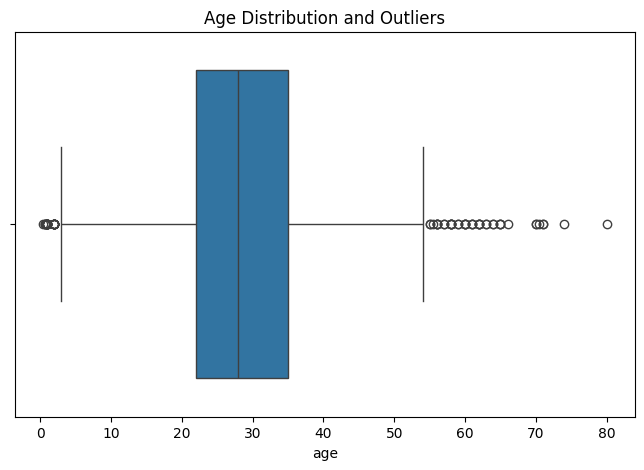

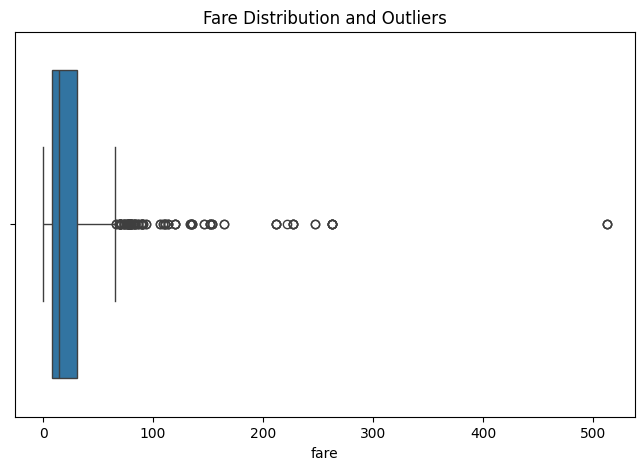

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check outliers in Age
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["age"])
plt.title("Age Distribution and Outliers")
plt.show()

# Check outliers in Fare
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["fare"])
plt.title("Fare Distribution and Outliers")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select numerical features
numeric_features = ['age', 'fare', 'sibsp', 'parch', 'family_size', 'is_alone']

# Standard Scaling
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[numeric_features] = standard_scaler.fit_transform(
    df_standard[numeric_features]
)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_features] = minmax_scaler.fit_transform(
    df_minmax[numeric_features]
)

print("Original data:")
display(df[numeric_features].head())

print("After StandardScaler:")
display(df_standard[numeric_features].head())

print("After MinMaxScaler:")
display(df_minmax[numeric_features].head())

Original data:


,age,fare,sibsp,parch,family_size,is_alone
0,22.0,7.2500,1,0,2,0
1,38.0,71.2833,1,0,2,0
2,26.0,7.9250,0,0,1,1
3,35.0,53.1000,1,0,2,0
4,35.0,8.0500,0,0,1,1


After StandardScaler:


,age,fare,sibsp,parch,family_size,is_alone
0,-0.565736,-0.502445,0.432793,-0.473674,0.059160,-1.231645
1,0.663861,0.786845,0.432793,-0.473674,0.059160,-1.231645
2,-0.258337,-0.488854,-0.474545,-0.473674,-0.560975,0.811922
3,0.433312,0.420730,0.432793,-0.473674,0.059160,-1.231645
4,0.433312,-0.486337,-0.474545,-0.473674,-0.560975,0.811922


After MinMaxScaler:


,age,fare,sibsp,parch,family_size,is_alone
0,0.271174,0.014151,0.125,0.0,0.1,0.0
1,0.472229,0.139136,0.125,0.0,0.1,0.0
2,0.321438,0.015469,0.000,0.0,0.0,1.0
3,0.434531,0.103644,0.125,0.0,0.1,0.0
4,0.434531,0.015713,0.000,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Make a copy of the dataset
encoded_df = df.copy()

# Ordinal encoding for class
class_order = ['First', 'Second', 'Third']

ordinal_encoder = OrdinalEncoder(categories=[class_order])

encoded_df['class_encoded'] = ordinal_encoder.fit_transform(
    encoded_df[['class']]
)

# One-Hot Encoding for nominal columns
encoded_df = pd.get_dummies(
    encoded_df,
    columns=['sex', 'embarked', 'deck'],
    drop_first=True
)

# Remove original class column
encoded_df = encoded_df.drop(columns=['class'])

print("Categorical encoding completed!")
display(encoded_df.head())

Categorical encoding completed!


,survived,pclass,age,sibsp,parch,fare,who,adult_male,embark_town,alive,...,sex_male,embarked_Q,embarked_S,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_Unknown
0,0,3,22.0,1,0,7.2500,man,True,Southampton,no,...,True,False,True,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,woman,False,Cherbourg,yes,...,False,False,False,False,True,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,woman,False,Southampton,yes,...,False,False,True,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,woman,False,Southampton,yes,...,False,False,True,False,True,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,man,True,Southampton,no,...,True,False,True,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Features and target
features = [
    'age', 'fare', 'sibsp', 'parch',
    'family_size', 'is_alone',
    'sex', 'embarked', 'deck', 'class'
]

X = df[features]
y = df['survived']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define feature types
numeric_features = [
    'age', 'fare', 'sibsp', 'parch',
    'family_size', 'is_alone'
]

nominal_features = ['sex', 'embarked', 'deck']

ordinal_features = ['class']

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Nominal categorical preprocessing
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Ordinal categorical preprocessing
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['First', 'Second', 'Third']]
    ))
])

# Combine all preprocessing
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('ordinal', ordinal_pipeline, ordinal_features)
])

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Train set shape: (712, 10)
Test set shape: (179, 10)
Processed train shape: (712, 17)
Processed test shape: (179, 17)


In [ ]:
# Create Family Size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Create Is Alone feature
df["is_alone"] = (df["family_size"] == 1).astype(int)

# Check the new features
df[["sibsp", "parch", "family_size", "is_alone"]].head()

NameError: name 'df' is not defined

In [ ]:
# Transform the complete dataset using the fitted preprocessor
X_processed = preprocessor.transform(X)

# Get the processed feature names
feature_names = preprocessor.get_feature_names_out()

# Create processed DataFrame
processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

# Add target column
processed_df['survived'] = y.values

# Save as CSV
processed_df.to_csv('processed_dataset.csv', index=False)

print("Processed dataset created successfully!")
print("Shape:", processed_df.shape)

display(processed_df.head())

Processed dataset created successfully!
Shape: (891, 18)


,numeric__age,numeric__fare,numeric__sibsp,numeric__parch,numeric__family_size,numeric__is_alone,nominal__sex_male,nominal__embarked_Q,nominal__embarked_S,nominal__deck_B,nominal__deck_C,nominal__deck_D,nominal__deck_E,nominal__deck_F,nominal__deck_G,nominal__deck_Unknown,ordinal__class,survived
0,-0.572716,-0.511601,0.478335,-0.466183,0.073412,-1.249460,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0
1,0.655652,0.821722,0.478335,-0.466183,0.073412,-1.249460,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,-0.265624,-0.497546,-0.465084,-0.466183,-0.556339,0.800346,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1
3,0.425333,0.443103,0.478335,-0.466183,0.073412,-1.249460,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.425333,-0.494943,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0


In [ ]:
from google.colab import files

files.download('processed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
import seaborn as sns

df = sns.load_dataset("titanic")
df.head()



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.to_csv("raw_dataset.csv", index=False)


In [ ]:
df.to_csv("raw_dataset.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Create Family Size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Create Is Alone
df["is_alone"] = (df["family_size"] == 1).astype(int)

# Check the new features
display(df[["sibsp", "parch", "family_size", "is_alone"]].head())

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 17


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size', 'is_alone']


In [ ]:
print("Data types:")
print(df.dtypes)

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
family_size       int64
is_alone          int64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  family_size  891 non-null    int64   
 16  is_alone     891 non-null    int64   
dtypes: bool(2), category(2), float64(2), int64(6), object(5)
memory usage: 94

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
family_size      0
is_alone         0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage.round(2))

Missing value percentage:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
family_size     0.00
is_alone        0.00
dtype: float64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 107


In [ ]:
display(df.describe())

,survived,pclass,age,sibsp,parch,fare,family_size,is_alone
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602,0.602694
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459,0.489615
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000


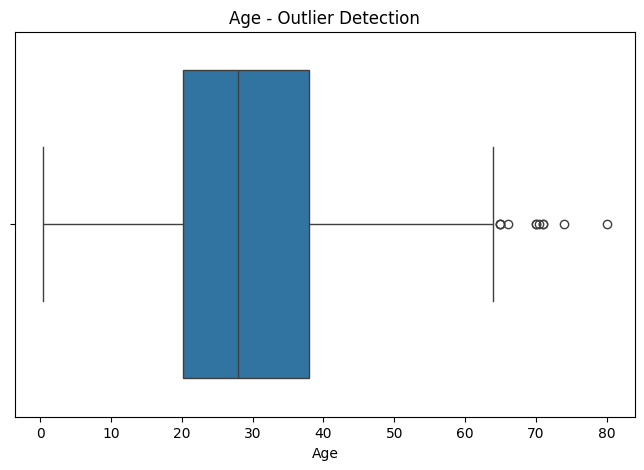

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["age"])

plt.title("Age - Outlier Detection")
plt.xlabel("Age")

plt.show()

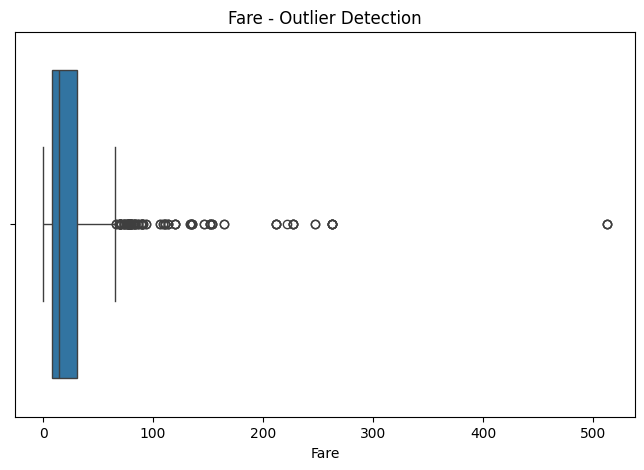

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["fare"])

plt.title("Fare - Outlier Detection")
plt.xlabel("Fare")

plt.show()

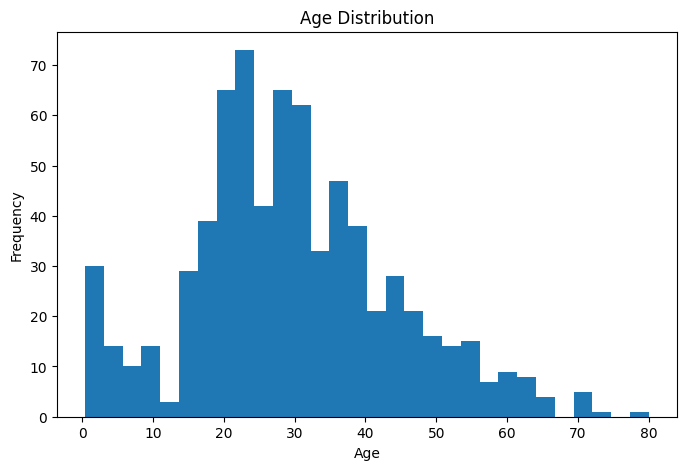

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"].dropna(), bins=30)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

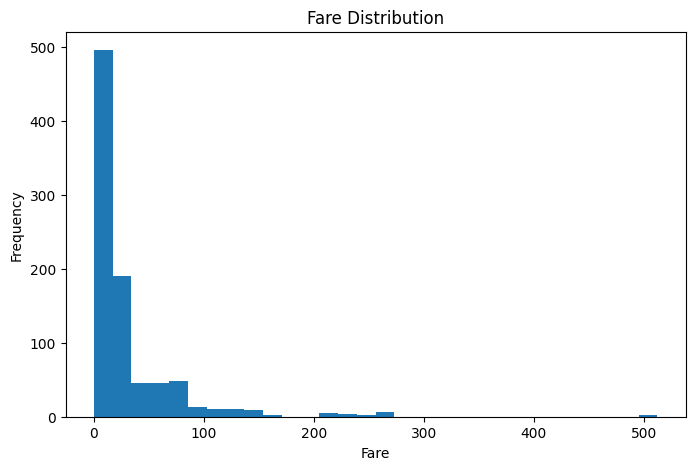

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["fare"].dropna(), bins=30)

plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")

plt.show()

In [ ]:
display(
    df[
        [
            "sibsp",
            "parch",
            "family_size",
            "is_alone"
        ]
    ].head(10)
)

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [ ]:
# Select features
features = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'family_size',
    'is_alone',
    'sex',
    'embarked',
    'deck',
    'class'
]

X = df[features]
y = df['survived']

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 10)
Testing data: (179, 10)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Numerical columns
numerical_features = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'family_size',
    'is_alone'
]

# Nominal categorical columns
nominal_features = [
    'sex',
    'embarked',
    'deck'
]

# Ordinal categorical column
ordinal_features = ['class']


# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# Nominal categorical preprocessing
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])


# Ordinal preprocessing
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['First', 'Second', 'Third']]
    ))
])


# Combine all preprocessing steps
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('ordinal', ordinal_pipeline, ordinal_features)
])


# IMPORTANT: fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)


print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)


Original training shape: (712, 10)
Processed training shape: (712, 16)
Original testing shape: (179, 10)
Processed testing shape: (179, 16)


In [ ]:
# Get the names of the processed features
feature_names = preprocessor.get_feature_names_out()

print("Processed feature names:")
print(feature_names)

Processed feature names:
['numerical__age' 'numerical__fare' 'numerical__sibsp' 'numerical__parch'
 'numerical__family_size' 'numerical__is_alone' 'nominal__sex_male'
 'nominal__embarked_Q' 'nominal__embarked_S' 'nominal__deck_B'
 'nominal__deck_C' 'nominal__deck_D' 'nominal__deck_E' 'nominal__deck_F'
 'nominal__deck_G' 'ordinal__class']


In [ ]:
# Convert processed training data into a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

# Add the target column
X_train_processed_df['survived'] = y_train

print("Processed dataset:")
display(X_train_processed_df.head())

Processed dataset:


,numerical__age,numerical__fare,numerical__sibsp,numerical__parch,numerical__family_size,numerical__is_alone,nominal__sex_male,nominal__embarked_Q,nominal__embarked_S,nominal__deck_B,nominal__deck_C,nominal__deck_D,nominal__deck_E,nominal__deck_F,nominal__deck_G,ordinal__class,survived
692,-0.081135,0.513812,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1
481,-0.081135,-0.662563,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
527,-0.081135,3.955399,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
855,-0.887827,-0.467874,-0.465084,0.727782,0.073412,-1.249460,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1
801,0.110934,-0.115977,0.478335,0.727782,0.703162,-1.249460,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


In [ ]:
import os

# Create data folder
os.makedirs("AI-ML-Data-Preprocessing/data", exist_ok=True)

# Save processed dataset
processed_path = "AI-ML-Data-Preprocessing/data/processed_dataset.csv"

X_train_processed_df.to_csv(processed_path, index=False)

print("Processed dataset saved successfully!")
print("File:", processed_path)

Processed dataset saved successfully!
File: AI-ML-Data-Preprocessing/data/processed_dataset.csv


In [ ]:
print("Processed dataset shape:", X_train_processed_df.shape)
print("Missing values:")
print(X_train_processed_df.isnull().sum().sum())

Processed dataset shape: (712, 17)
Missing values:
0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Select age values
age_original = X_train[['age']].copy()

# Fill missing values temporarily for comparison
age_filled = age_original.fillna(age_original['age'].median())

# Standard Scaling
standard_scaler = StandardScaler()
age_standard = standard_scaler.fit_transform(age_filled)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
age_minmax = minmax_scaler.fit_transform(age_filled)

# Print some values
print("Original Age:")
print(age_filled.head())

print("\nStandard Scaled Age:")
print(age_standard[:5].flatten())

print("\nMin-Max Scaled Age:")
print(age_minmax[:5].flatten())

Original Age:
      age
692  28.5
481  28.5
527  28.5
855  18.0
801  31.0

Standard Scaled Age:
[-0.08113533 -0.08113533 -0.08113533 -0.88782719  0.11093416]

Min-Max Scaled Age:
[0.35285248 0.35285248 0.35285248 0.22090978 0.3842674 ]


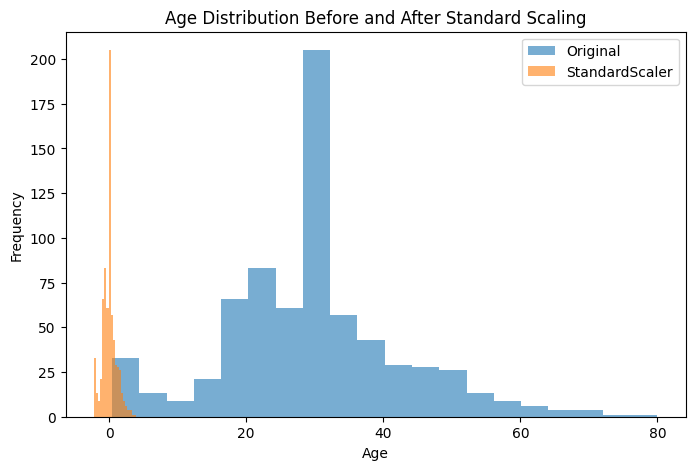

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(age_filled['age'], bins=20, alpha=0.6, label='Original')
plt.hist(age_standard.flatten(), bins=20, alpha=0.6, label='StandardScaler')

plt.title("Age Distribution Before and After Standard Scaling")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

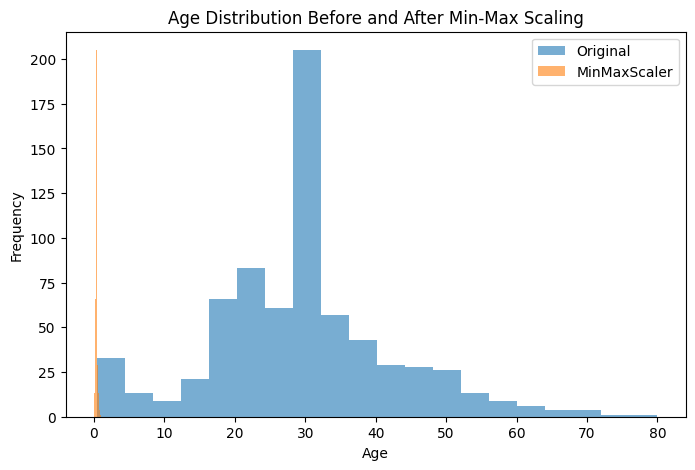

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(age_filled['age'], bins=20, alpha=0.6, label='Original')
plt.hist(age_minmax.flatten(), bins=20, alpha=0.6, label='MinMaxScaler')

plt.title("Age Distribution Before and After Min-Max Scaling")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
print("Processed dataset shape:", X_train_processed_df.shape)

print("\nColumn names:")
print(X_train_processed_df.columns.tolist())

print("\nMissing values:")
print(X_train_processed_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(X_train_processed_df.duplicated().sum())

display(X_train_processed_df.head())

Processed dataset shape: (712, 17)

Column names:
['numerical__age', 'numerical__fare', 'numerical__sibsp', 'numerical__parch', 'numerical__family_size', 'numerical__is_alone', 'nominal__sex_male', 'nominal__embarked_Q', 'nominal__embarked_S', 'nominal__deck_B', 'nominal__deck_C', 'nominal__deck_D', 'nominal__deck_E', 'nominal__deck_F', 'nominal__deck_G', 'ordinal__class', 'survived']

Missing values:
0

Duplicate rows:
72


,numerical__age,numerical__fare,numerical__sibsp,numerical__parch,numerical__family_size,numerical__is_alone,nominal__sex_male,nominal__embarked_Q,nominal__embarked_S,nominal__deck_B,nominal__deck_C,nominal__deck_D,nominal__deck_E,nominal__deck_F,nominal__deck_G,ordinal__class,survived
692,-0.081135,0.513812,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1
481,-0.081135,-0.662563,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
527,-0.081135,3.955399,-0.465084,-0.466183,-0.556339,0.800346,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
855,-0.887827,-0.467874,-0.465084,0.727782,0.073412,-1.249460,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1
801,0.110934,-0.115977,0.478335,0.727782,0.703162,-1.249460,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


In [ ]:
import os

os.makedirs("AI-ML-Data-Preprocessing/data", exist_ok=True)

final_path = "AI-ML-Data-Preprocessing/data/processed_dataset.csv"

X_train_processed_df.to_csv(final_path, index=False)

print("✅ Final processed dataset exported successfully!")
print(final_path)

✅ Final processed dataset exported successfully!
AI-ML-Data-Preprocessing/data/processed_dataset.csv


In [ ]:
print("========== PROJECT SUMMARY ==========")
print("Original dataset:", df.shape)
print("Training dataset:", X_train.shape)
print("Testing dataset:", X_test.shape)
print("Processed training dataset:", X_train_processed_df.shape)
print("Missing values after preprocessing:",
      X_train_processed_df.isnull().sum().sum())
print("=====================================")

========== PROJECT SUMMARY ==========
Original dataset: (891, 17)
Training dataset: (712, 10)
Testing dataset: (179, 10)
Processed training dataset: (712, 17)
Missing values after preprocessing: 0
